In [1]:
#importamos las varaibles
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ( accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay)

## Cargamos el DataSet

In [3]:
iris = load_iris(as_frame=True)

In [4]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [5]:
dfIris = iris.frame
dfIris.head(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0


In [6]:
dfIris.tail(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [7]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [8]:
dfIris.rename(columns={"target" : "species"}, inplace=True)

In [9]:
dfIris["species"] = dfIris["species"].map (
{
    0: "setosa",
    1: "versicolor",
    2:"virginica"
}
)

## Variables predictoras y variable objetivo
X (Variables predictoras) son aquellas qu eme permiten hacer la prediccion
y (objetivo) Lo que quiero predecir

In [10]:
#Variables predictoras
X = dfIris.drop(columns=["species"])

In [11]:
#Variable objetivo
y = dfIris["species"]

In [12]:
print("----Variables predictoras----")
print(X.columns)
print("----Variables Objetivo----")
print(y.name)

----Variables predictoras----
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')
----Variables Objetivo----
species


##Division del conjunto de datos

*Training Set:* Datos para entrenamiento (80%)
*Testing Set:* Datos no vistos por el modelo, para prueba. (20%)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, #Variables predictoras
    y, #Variable objetivo
    test_size = 0.20,
    random_state=42,
    stratify=y
)

In [14]:
print("X_train: ", X_train.shape)
print("X_test: ", X_test.shape)
print("-----------------------")
print("y_train: ", y_train.shape)
print("y_test: ", y_test.shape)

X_train:  (120, 4)
X_test:  (30, 4)
-----------------------
y_train:  (120,)
y_test:  (30,)


## Escalado de las variables

In [15]:
scaler = StandardScaler()

In [16]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
print ("----Datos sin escalar----")
print(X_train)
print ("----Escalados----")
# En NumPy, [:5] significa "trae las primeras 5 filas"
print(X_train_scaled[:5])


----Datos sin escalar----
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
8                  4.4               2.9                1.4               0.2
106                4.9               2.5                4.5               1.7
76                 6.8               2.8                4.8               1.4
9                  4.9               3.1                1.5               0.1
89                 5.5               2.5                4.0               1.3
..                 ...               ...                ...               ...
37                 4.9               3.6                1.4               0.1
2                  4.7               3.2                1.3               0.2
33                 5.5               4.2                1.4               0.2
52                 6.9               3.1                4.9               1.5
3                  4.6               3.1                1.5               0.2

[120 rows x 4 columns]
----Escalados-

## Entranamiento del modelo

In [18]:
#Creamos una instancia del algoritmo
modelo = KNeighborsClassifier(
    n_neighbors = 3
)

In [19]:
#Entrenamos con los datos del entrenamiento
modelo.fit(
    X_train_scaled,
    y_train
)

KNeighborsClassifier(n_neighbors=3)

In [20]:
#Entrenamos con los datos de entrenamiento
modelo.fit(
    X_train_scaled,
    y_train
)

KNeighborsClassifier(n_neighbors=3)

In [21]:
prediccion = modelo.predict(X_test_scaled)

In [22]:
pd.DataFrame({
    "Especie real": y_test.values,
    "Especie predicha" : prediccion
}).head(20)

,Especie real,Especie predicha
0,setosa,setosa
1,virginica,virginica
2,versicolor,versicolor
3,versicolor,versicolor
4,setosa,setosa
5,versicolor,versicolor
6,setosa,setosa
7,setosa,setosa
8,virginica,virginica
9,versicolor,versicolor


##Evaluacion del modelo

*Las metricas a usar son: accuracy, presicion, recall, f1-score*

In [24]:
#Accurracy
accuracy = accuracy_score(y_test, prediccion)

In [25]:
print ( f"Accurracy / Exactitud del modelo es: {accuracy: .4f}")

Accurracy / Exactitud del modelo es:  0.9333


In [26]:
#Matriz de confusión

matrizConfusion = confusion_matrix(y_test, prediccion)
matrizConfusion_df = pd.DataFrame(
    matrizConfusion,
    index = modelo.classes_,
    columns = modelo.classes_
)

In [27]:
matrizConfusion_df

,setosa,versicolor,virginica
setosa,10,0,0
versicolor,0,10,0
virginica,0,2,8


In [28]:
# Matriz de metricas: Classification Report
print ( classification_report(y_test, prediccion))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



VARIABLES DE IMPORTANCIA

In [30]:
##modelo.feature_importances_
corr = dfIris.corr(numeric_only=True)

In [31]:
import seaborn as sns

<Axes: >

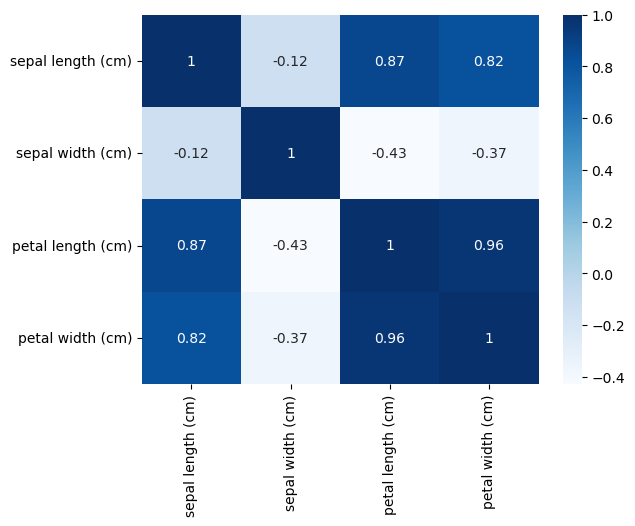

In [32]:
sns.heatmap ( corr, annot=True, cmap="Blues")